### Without Pipeline

In [1]:
import numpy as np
import pandas as pd

In [2]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer


In [3]:
df = pd.read_csv('covid.csv')

In [4]:
df.head()

,age,gender,fever,cough,city,has_covid
0,60,Male,103.0,Mild,Kolkata,No
1,27,Male,100.0,Mild,Delhi,Yes
2,42,Male,101.0,Mild,Delhi,No
3,31,Female,98.0,Mild,Kolkata,No
4,65,Female,101.0,Mild,Mumbai,No


In [5]:
df['has_covid'].value_counts()

has_covid
No     55
Yes    45
Name: count, dtype: int64

In [6]:
df.isnull().sum()

age           0
gender        0
fever        10
cough         0
city          0
has_covid     0
dtype: int64

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['has_covid']),df['has_covid'],
                                                test_size=0.2,random_state=42)

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_le = le.fit_transform(y_train)
y_test_le = le.transform(y_test)

In [9]:
X_train

,age,gender,fever,cough,city
55,81,Female,101.0,Mild,Mumbai
88,5,Female,100.0,Mild,Kolkata
26,19,Female,100.0,Mild,Kolkata
42,27,Male,100.0,Mild,Delhi
69,73,Female,103.0,Mild,Delhi
...,...,...,...,...,...
60,24,Female,102.0,Strong,Bangalore
71,75,Female,104.0,Strong,Delhi
14,51,Male,104.0,Mild,Bangalore
92,82,Female,102.0,Strong,Kolkata


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Simple Imputer
trf1 = ColumnTransformer([
    ('si_cols',SimpleImputer(strategy='mean'),[2])
],remainder='passthrough')

In [11]:
X_train_trf1 = trf1.fit_transform(X_train)
X_train_trf1

array([[101.0, 81, 'Female', 'Mild', 'Mumbai'],
       [100.0, 5, 'Female', 'Mild', 'Kolkata'],
       [100.0, 19, 'Female', 'Mild', 'Kolkata'],
       [100.0, 27, 'Male', 'Mild', 'Delhi'],
       [103.0, 73, 'Female', 'Mild', 'Delhi'],
       [103.0, 70, 'Male', 'Strong', 'Kolkata'],
       [102.0, 49, 'Female', 'Mild', 'Delhi'],
       [101.0, 51, 'Female', 'Strong', 'Kolkata'],
       [101.0, 64, 'Female', 'Mild', 'Delhi'],
       [101.0, 83, 'Female', 'Mild', 'Kolkata'],
       [98.0, 65, 'Female', 'Mild', 'Mumbai'],
       [104.0, 18, 'Female', 'Mild', 'Bangalore'],
       [103.0, 16, 'Female', 'Mild', 'Bangalore'],
       [104.0, 16, 'Male', 'Mild', 'Kolkata'],
       [100.0, 27, 'Male', 'Mild', 'Kolkata'],
       [101.0, 84, 'Female', 'Mild', 'Bangalore'],
       [104.0, 51, 'Male', 'Mild', 'Kolkata'],
       [102.0, 69, 'Female', 'Mild', 'Bangalore'],
       [102.0, 82, 'Female', 'Strong', 'Bangalore'],
       [103.0, 69, 'Female', 'Mild', 'Kolkata'],
       [104.0, 44, 'Male',

In [12]:
X_train_trf1.shape

(80, 5)

In [13]:
from sklearn.preprocessing import OneHotEncoder

# one hot encoding
trf2 = ColumnTransformer([
    ('ohe_cols',OneHotEncoder(sparse_output=False,drop='first'),[2,4])
],remainder='passthrough')

In [14]:
X_train_trf2 = trf2.fit_transform(X_train_trf1)
X_train_trf2

array([[0.0, 0.0, 0.0, 1.0, 101.0, 81, 'Mild'],
       [0.0, 0.0, 1.0, 0.0, 100.0, 5, 'Mild'],
       [0.0, 0.0, 1.0, 0.0, 100.0, 19, 'Mild'],
       [1.0, 1.0, 0.0, 0.0, 100.0, 27, 'Mild'],
       [0.0, 1.0, 0.0, 0.0, 103.0, 73, 'Mild'],
       [1.0, 0.0, 1.0, 0.0, 103.0, 70, 'Strong'],
       [0.0, 1.0, 0.0, 0.0, 102.0, 49, 'Mild'],
       [0.0, 0.0, 1.0, 0.0, 101.0, 51, 'Strong'],
       [0.0, 1.0, 0.0, 0.0, 101.0, 64, 'Mild'],
       [0.0, 0.0, 1.0, 0.0, 101.0, 83, 'Mild'],
       [0.0, 0.0, 0.0, 1.0, 98.0, 65, 'Mild'],
       [0.0, 0.0, 0.0, 0.0, 104.0, 18, 'Mild'],
       [0.0, 0.0, 0.0, 0.0, 103.0, 16, 'Mild'],
       [1.0, 0.0, 1.0, 0.0, 104.0, 16, 'Mild'],
       [1.0, 0.0, 1.0, 0.0, 100.0, 27, 'Mild'],
       [0.0, 0.0, 0.0, 0.0, 101.0, 84, 'Mild'],
       [1.0, 0.0, 1.0, 0.0, 104.0, 51, 'Mild'],
       [0.0, 0.0, 0.0, 0.0, 102.0, 69, 'Mild'],
       [0.0, 0.0, 0.0, 0.0, 102.0, 82, 'Strong'],
       [0.0, 0.0, 1.0, 0.0, 103.0, 69, 'Mild'],
       [1.0, 0.0, 0.0, 1.0, 104.0, 4

In [15]:
X_train_trf2.shape

(80, 7)

In [16]:
from sklearn.preprocessing import OrdinalEncoder

# ordinal encoding
trf3 = ColumnTransformer([
    ('oe_cols',OrdinalEncoder(categories=[['Mild','Strong']]),[6])
],remainder='passthrough')

In [17]:
X_train_trf3 = trf3.fit_transform(X_train_trf2)
X_train_trf3

array([[0.0, 0.0, 0.0, 0.0, 1.0, 101.0, 81],
       [0.0, 0.0, 0.0, 1.0, 0.0, 100.0, 5],
       [0.0, 0.0, 0.0, 1.0, 0.0, 100.0, 19],
       [0.0, 1.0, 1.0, 0.0, 0.0, 100.0, 27],
       [0.0, 0.0, 1.0, 0.0, 0.0, 103.0, 73],
       [1.0, 1.0, 0.0, 1.0, 0.0, 103.0, 70],
       [0.0, 0.0, 1.0, 0.0, 0.0, 102.0, 49],
       [1.0, 0.0, 0.0, 1.0, 0.0, 101.0, 51],
       [0.0, 0.0, 1.0, 0.0, 0.0, 101.0, 64],
       [0.0, 0.0, 0.0, 1.0, 0.0, 101.0, 83],
       [0.0, 0.0, 0.0, 0.0, 1.0, 98.0, 65],
       [0.0, 0.0, 0.0, 0.0, 0.0, 104.0, 18],
       [0.0, 0.0, 0.0, 0.0, 0.0, 103.0, 16],
       [0.0, 1.0, 0.0, 1.0, 0.0, 104.0, 16],
       [0.0, 1.0, 0.0, 1.0, 0.0, 100.0, 27],
       [0.0, 0.0, 0.0, 0.0, 0.0, 101.0, 84],
       [0.0, 1.0, 0.0, 1.0, 0.0, 104.0, 51],
       [0.0, 0.0, 0.0, 0.0, 0.0, 102.0, 69],
       [1.0, 0.0, 0.0, 0.0, 0.0, 102.0, 82],
       [0.0, 0.0, 0.0, 1.0, 0.0, 103.0, 69],
       [0.0, 1.0, 0.0, 0.0, 1.0, 104.0, 44],
       [0.0, 1.0, 0.0, 0.0, 1.0, 102.0, 74],
       [1.0,

In [18]:
X_train_trf3.shape

(80, 7)

In [19]:
from sklearn.preprocessing import PowerTransformer

# Power Transformer
trf4 = ColumnTransformer([
    ('oe_cols',PowerTransformer(),[0,1,2,3,4,5,6])
],remainder='passthrough')

In [20]:
X_train_trf4 = trf4.fit_transform(X_train_trf3)
X_train_trf4

array([[-0.81649658, -0.83793058, -0.5       , -0.6352234 ,  2.17124059,
         0.01262494,  1.41495371],
       [-0.81649658, -0.83793058, -0.5       ,  1.5742493 , -0.46056619,
        -0.51251366, -1.88106831],
       [-0.81649658, -0.83793058, -0.5       ,  1.5742493 , -0.46056619,
        -0.51251366, -0.95016536],
       [-0.81649658,  1.19341628,  2.        , -0.6352234 , -0.46056619,
        -0.51251366, -0.54932751],
       [-0.81649658, -0.83793058,  2.        , -0.6352234 , -0.46056619,
         1.04244101,  1.16951806],
       [ 1.22474487,  1.19341628, -0.5       ,  1.5742493 , -0.46056619,
         1.04244101,  1.0746708 ],
       [-0.81649658, -0.83793058,  2.        , -0.6352234 , -0.46056619,
         0.53089138,  0.35698586],
       [ 1.22474487, -0.83793058, -0.5       ,  1.5742493 , -0.46056619,
         0.01262494,  0.43013136],
       [-0.81649658, -0.83793058,  2.        , -0.6352234 , -0.46056619,
         0.01262494,  0.87984688],
       [-0.81649658, -0.8379

In [21]:
X_train_trf4.shape

(80, 7)

In [22]:
from sklearn.preprocessing import StandardScaler

# Scaling
trf5 = ColumnTransformer([
    ('scale',StandardScaler(),[0,1,2,3,4,5,6])
#     ('scale',MinMaxScaler(),[0,4,7,8,9,12,13])
])

In [23]:
X_train_trf5 = trf5.fit_transform(X_train_trf4)
X_train_trf5

array([[-0.81649658, -0.83793058, -0.5       , -0.6352234 ,  2.17124059,
         0.01262494,  1.41495371],
       [-0.81649658, -0.83793058, -0.5       ,  1.5742493 , -0.46056619,
        -0.51251366, -1.88106831],
       [-0.81649658, -0.83793058, -0.5       ,  1.5742493 , -0.46056619,
        -0.51251366, -0.95016536],
       [-0.81649658,  1.19341628,  2.        , -0.6352234 , -0.46056619,
        -0.51251366, -0.54932751],
       [-0.81649658, -0.83793058,  2.        , -0.6352234 , -0.46056619,
         1.04244101,  1.16951806],
       [ 1.22474487,  1.19341628, -0.5       ,  1.5742493 , -0.46056619,
         1.04244101,  1.0746708 ],
       [-0.81649658, -0.83793058,  2.        , -0.6352234 , -0.46056619,
         0.53089138,  0.35698586],
       [ 1.22474487, -0.83793058, -0.5       ,  1.5742493 , -0.46056619,
         0.01262494,  0.43013136],
       [-0.81649658, -0.83793058,  2.        , -0.6352234 , -0.46056619,
         0.01262494,  0.87984688],
       [-0.81649658, -0.8379

In [24]:
X_train_trf5.shape

(80, 7)

In [25]:
from sklearn.feature_selection import SelectKBest,mutual_info_classif

# Feature selection
trf6 = SelectKBest(score_func=mutual_info_classif,k=6)

In [26]:
X_train_trf6 = trf6.fit_transform(X_train_trf5,y_train_le)
X_train_trf6

array([[-0.83793058, -0.5       , -0.6352234 ,  2.17124059,  0.01262494,
         1.41495371],
       [-0.83793058, -0.5       ,  1.5742493 , -0.46056619, -0.51251366,
        -1.88106831],
       [-0.83793058, -0.5       ,  1.5742493 , -0.46056619, -0.51251366,
        -0.95016536],
       [ 1.19341628,  2.        , -0.6352234 , -0.46056619, -0.51251366,
        -0.54932751],
       [-0.83793058,  2.        , -0.6352234 , -0.46056619,  1.04244101,
         1.16951806],
       [ 1.19341628, -0.5       ,  1.5742493 , -0.46056619,  1.04244101,
         1.0746708 ],
       [-0.83793058,  2.        , -0.6352234 , -0.46056619,  0.53089138,
         0.35698586],
       [-0.83793058, -0.5       ,  1.5742493 , -0.46056619,  0.01262494,
         0.43013136],
       [-0.83793058,  2.        , -0.6352234 , -0.46056619,  0.01262494,
         0.87984688],
       [-0.83793058, -0.5       ,  1.5742493 , -0.46056619,  0.01262494,
         1.47473969],
       [-0.83793058, -0.5       , -0.6352234 ,  2.

In [27]:
X_train_trf6.shape

(80, 6)

In [28]:
from sklearn.svm import SVC

trf7 = SVC(kernel='linear')

In [29]:
trf7.fit(X_train_trf6,y_train_le)

SVC(kernel='linear')

In [30]:
ypred = trf7.predict(X_train_trf6)
ypred

array([0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1])

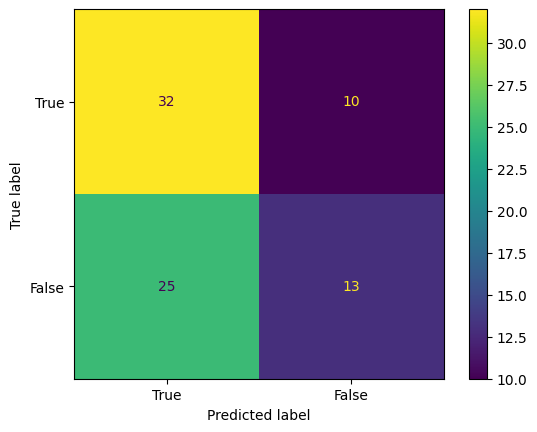

Training Measures:
Accuracy: 0.562500
Precision: 0.565217
Recall: 0.342105
F1_Score: 0.426230
Matthews correlation coefficient: 0.114760


In [31]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import matthews_corrcoef, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

accu = accuracy_score(y_train_le,ypred)
prec = precision_score(y_train_le,ypred)
rec = recall_score(y_train_le,ypred)
fs = f1_score(y_train_le,ypred)
cm = confusion_matrix(y_train_le,ypred)
mcc = matthews_corrcoef(y_train_le,ypred)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [True, False])
cm_display.plot()
plt.show()

print('Training Measures:')
print('Accuracy: %f' % accu)
print('Precision: %f' % prec)
print('Recall: %f' % rec)
print('F1_Score: %f' % fs)
print('Matthews correlation coefficient: %f' % mcc)

## With Pipeline

In [32]:
from sklearn.compose import ColumnTransformer

In [33]:
X_train.columns

Index(['age', 'gender', 'fever', 'cough', 'city'], dtype='object')

In [34]:
df['city'].nunique()

4

In [35]:
# Simple Imputer
trf1 = ColumnTransformer([
    ('si_cols',SimpleImputer(strategy='mean'),[2])
],remainder='passthrough')

In [36]:
from sklearn.preprocessing import OneHotEncoder

# one hot encoding
trf2 = ColumnTransformer([
    ('ohe_cols',OneHotEncoder(sparse_output=False,drop='first'),[2,4])
],remainder='passthrough')

In [37]:
from sklearn.preprocessing import OrdinalEncoder

# ordinal encoding
trf3 = ColumnTransformer([
    ('oe_cols',OrdinalEncoder(categories=[['Mild','Strong']]),[6])
],remainder='passthrough')

In [38]:
from sklearn.preprocessing import PowerTransformer

# Power Transformer
trf4 = ColumnTransformer([
    ('pt_cols',PowerTransformer(),[0,1,2,3,4,5,6])
],remainder='passthrough')

In [39]:
from sklearn.preprocessing import StandardScaler

# Scaling
trf5 = ColumnTransformer([
    ('scale',StandardScaler(),[0,1,2,3,4,5,6])
#     ('scale',MinMaxScaler(),[0,4,7,8,9,12,13])
])

In [40]:
from sklearn.feature_selection import SelectKBest,mutual_info_classif

# Feature selection
trf6 = SelectKBest(score_func=mutual_info_classif,k=6)

In [41]:
from sklearn.svm import SVC

trf7 = SVC(kernel = 'linear')

In [42]:
from sklearn.pipeline import Pipeline


pipe = Pipeline([
    ('trf1',trf1),
    ('trf2',trf2),
    ('trf3',trf3),
    ('trf4',trf4),
    ('trf5',trf5),
    ('trf6',trf6),
    ('trf7',trf7)
])

In [43]:
pipe.fit(X_train,y_train_le)


Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('si_cols', SimpleImputer(),
                                                  [2])])),
                ('trf2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe_cols',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  [2, 4])])),
                ('trf3',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('oe_cols',
                                                  OrdinalEncoder(categories=[['Mild',
                                                                              'Strong']]),
                                                  [6])])),
                ('trf4',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('pt_cols', PowerTransformer(),
                                                  [0, 1, 2, 3, 4, 5, 6])])),
                ('trf5',
                 ColumnTransformer(transformers=[('scale', StandardScaler(),
                                                  [0, 1, 2, 3, 4, 5, 6])])),
                ('trf6',
                 SelectKBest(k=6,
                             score_func=<function mutual_info_classif at 0x0000013313F60CA0>)),
                ('trf7', SVC(kernel='linear'))])

In [44]:
pipe.named_steps

{'trf1': ColumnTransformer(remainder='passthrough',
                   transformers=[('si_cols', SimpleImputer(), [2])]),
 'trf2': ColumnTransformer(remainder='passthrough',
                   transformers=[('ohe_cols',
                                  OneHotEncoder(drop='first',
                                                sparse_output=False),
                                  [2, 4])]),
 'trf3': ColumnTransformer(remainder='passthrough',
                   transformers=[('oe_cols',
                                  OrdinalEncoder(categories=[['Mild',
                                                              'Strong']]),
                                  [6])]),
 'trf4': ColumnTransformer(remainder='passthrough',
                   transformers=[('pt_cols', PowerTransformer(),
                                  [0, 1, 2, 3, 4, 5, 6])]),
 'trf5': ColumnTransformer(transformers=[('scale', StandardScaler(),
                                  [0, 1, 2, 3, 4, 5, 6])]),
 'trf6': Sele

In [45]:
pipe.named_steps['trf1'].get_feature_names_out()

array(['si_cols__fever', 'remainder__age', 'remainder__gender',
       'remainder__cough', 'remainder__city'], dtype=object)

In [46]:
# Predict

ypred = pipe.predict(X_train)
yhat = pipe.predict(X_test)

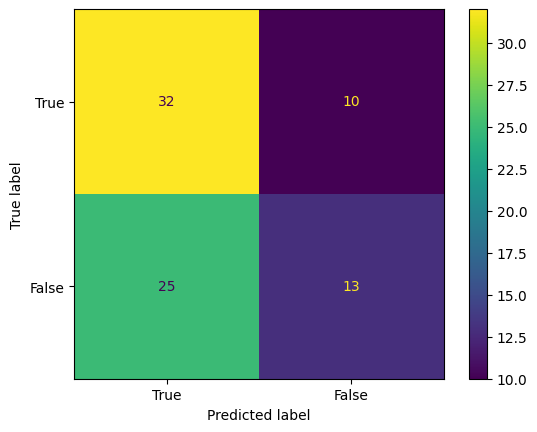

Training Measures:
Accuracy: 0.562500
Precision: 0.565217
Recall: 0.342105
F1_Score: 0.426230
Matthews correlation coefficient: 0.114760


In [47]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import matthews_corrcoef, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

accu = accuracy_score(y_train_le,ypred)
prec = precision_score(y_train_le,ypred)
rec = recall_score(y_train_le,ypred)
fs = f1_score(y_train_le,ypred)
cm = confusion_matrix(y_train_le,ypred)
mcc = matthews_corrcoef(y_train_le,ypred)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [True, False])
cm_display.plot()
plt.show()

print('Training Measures:')
print('Accuracy: %f' % accu)
print('Precision: %f' % prec)
print('Recall: %f' % rec)
print('F1_Score: %f' % fs)
print('Matthews correlation coefficient: %f' % mcc)

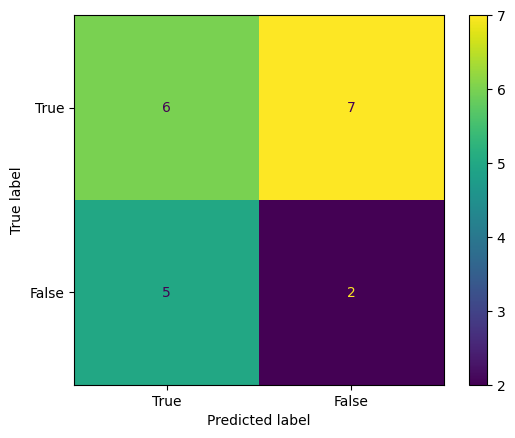

Test Measures:
Accuracy: 0.400000
Precision: 0.222222
Recall: 0.285714
F1_Score: 0.250000
Matthews correlation coefficient: -0.242320


In [48]:
accu = accuracy_score(y_test_le,yhat)
prec = precision_score(y_test_le,yhat)
rec = recall_score(y_test_le,yhat)
fs = f1_score(y_test_le,yhat)
mcc = matthews_corrcoef(y_test_le,yhat)
cm = confusion_matrix(y_test_le,yhat)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [True, False])
cm_display.plot()
plt.show()
print('Test Measures:')
print('Accuracy: %f' % accu)
print('Precision: %f' % prec)
print('Recall: %f' % rec)
print('F1_Score: %f' % fs)
print('Matthews correlation coefficient: %f' % mcc)
# print('Confusion Matrix: %f' % cm)

In [49]:
# cross validation using cross_val_score
from sklearn.model_selection import cross_val_score

cross_val_score(pipe, X_train, y_train_le, cv=5, scoring='accuracy').mean()

0.4375

In [50]:
# export 
import pickle
pickle.dump(pipe,open('pipe.pkl','wb'))

In [51]:
pipe = pickle.load(open('pipe.pkl','rb'))

In [52]:
X_test[1:2].values

array([[83, 'Male', 98.0, 'Mild', 'Delhi']], dtype=object)

In [53]:
import numpy as np
# Assume user input
test_input = np.array(X_test[1:2].values,dtype=object).reshape(1,5)
test_input

array([[83, 'Male', 98.0, 'Mild', 'Delhi']], dtype=object)

In [54]:
pipe.predict(test_input)

C:\Users\JAWAD\anaconda3\envs\python310\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


array([0])

In [55]:
y_test[:1].values

array(['No'], dtype=object)

In [56]:
print("Class Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))


Class Mapping: {'No': 0, 'Yes': 1}
